# Problem Definition

Dota 2 is a 5v5 multiplayer online battle arena game that I have played heavily over the past year. In Assignment 1, I focused on whether my post-match individual performance statistics were related to winning or losing. That project showed that end-of-game metrics such as economy, damage, and KDA carry strong predictive signal, but it also revealed an important limitation: those features are observed only after the game has already unfolded.

For this extension, I wanted to ask a harder and more interesting question: how much can be predicted before the game really begins? Instead of relying on post-game performance numbers, this project uses prematch and draft-context information to study two classification tasks. The first task is to predict whether a match will end in a win or a loss. The second task is to predict whether the match will be short, medium, or long.

This framing makes the problem more realistic and more challenging. Draft composition, party size, rank context, side, and team role balance may all shape how a game develops, but they do not determine the outcome directly in the way post-match statistics often do. By shifting the analysis from “what happened by the end of the game?” to “what can already be inferred from the starting context?”, this project extends the first assignment into a more meaningful predictive setting.

# Data Preprocessing

As in Assignment 1, I used OpenDota as the main data source. OpenDota provides structured access to public Dota 2 match data through an API, which makes it possible to move beyond the game client’s limited match history interface and construct a dataset suitable for machine learning analysis.

To build the dataset, I extended my earlier extraction pipeline. The script first queried the OpenDota API for my 500 most recent matches, then downloaded full match-level information for each one. In Assignment 1, I only kept a small set of end-of-game personal performance variables. In this notebook, I expanded the extraction process to include a much richer set of contextual fields, especially those available before or at the start of the match. These included my selected hero, ally and enemy hero lineups, side (Radiant or Dire), party size, average rank, game mode, lobby type, region, patch/version, and team role composition. I also stored some post-match and item-related fields in the master table so that the full extraction process would not need to be repeated later, but these were not used as predictors in the prematch models.

Because calling the API for every match is slow, I saved the extracted data into CSV files so the notebook could be rerun efficiently without repeatedly requesting the same information. After loading the saved data into pandas, I performed several preprocessing steps to prepare it for analysis. First, I removed rows missing the essential fields required for the prematch tasks, such as match outcome, duration, hero identity, and ally/enemy hero lists. Next, I encoded win as a numeric binary target, with 1 representing a win and 0 representing a loss. For the second task, I converted continuous match duration into three balanced categories — short, medium, and long — based on the empirical distribution of match lengths in the dataset.

The draft-related columns required additional processing because the ally and enemy hero lists were stored as JSON-like structures. I parsed these fields and then transformed them into machine-readable features. My own hero was one-hot encoded, while ally and enemy hero lineups were represented with multi-hot encoding so that each match could capture the full draft composition. I also kept structured numeric context variables such as party size and average rank, and included role-count summaries for both teams. The result was a high-dimensional prematch feature matrix that could be used consistently across the two prediction tasks.

In [ ]:
import os
import json
import time
import requests
import pandas as pd

ACCOUNT_ID = 392710669
BASE = "https://api.opendota.com/api"

# ----- API / runtime settings -----
LIST_LIMIT = 100
MAX_MATCHES = 500
SLEEP = 1.0
TIMEOUT = 30
RETRIES = 5

RAW_DIR = "opendota_raw_matches"
OUT_CSV = "opendota_master.csv"

# keep a few item timings for later itemization analysis
INTERESTING_ITEMS = {
    "black_king_bar",
    "blink",
    "manta",
    "shadow_blade",
    "silver_edge",
    "aghanims_scepter",
    "boots",
    "power_treads",
    "phase_boots",
    "arcane_boots",
    "travel_boots",
    "glimmer_cape",
    "force_staff",
    "lotus_orb",
    "linkens_sphere",
}

session = requests.Session()
os.makedirs(RAW_DIR, exist_ok=True)


# -------------------------------
# Basic helpers
# -------------------------------
def get_json(url, params=None, retries=RETRIES):
    """
    GET request with simple retry / rate-limit handling.
    """
    for i in range(retries):
        r = session.get(url, params=params, timeout=TIMEOUT)
        if r.status_code == 429:
            time.sleep(2 + 2 * i)
            continue
        r.raise_for_status()
        return r.json()
    raise RuntimeError(f"Failed after retries: {url}")


def fetch_constants(resource):
    """
    GET /constants/{resource}
    """
    return get_json(f"{BASE}/constants/{resource}")


def fetch_match_list():
    """
    Downloads the user's recent matches from:
    /players/{account_id}/matches
    """
    rows = []
    offset = 0

    while True:
        batch = get_json(
            f"{BASE}/players/{ACCOUNT_ID}/matches",
            params={"limit": LIST_LIMIT, "offset": offset}
        )

        if not batch:
            break

        rows.extend(batch)
        offset += LIST_LIMIT

        if MAX_MATCHES is not None and len(rows) >= MAX_MATCHES:
            rows = rows[:MAX_MATCHES]
            break

        time.sleep(SLEEP)

    return rows


def cached_match_json(match_id):
    """
    Reads a cached match JSON if present, otherwise downloads and saves it.
    """
    path = os.path.join(RAW_DIR, f"{match_id}.json")

    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)

    data = get_json(f"{BASE}/matches/{match_id}")

    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f)

    return data


def build_hero_maps(heroes_constants):
    """
    Builds:
      hero_id -> localized_name
      hero_id -> roles list
    """
    hero_id_to_name = {}
    hero_id_to_roles = {}

    if isinstance(heroes_constants, dict):
        for _, obj in heroes_constants.items():
            if isinstance(obj, dict) and obj.get("id") is not None:
                hid = int(obj["id"])
                hero_id_to_name[hid] = obj.get("localized_name", str(hid))
                hero_id_to_roles[hid] = obj.get("roles", [])
    elif isinstance(heroes_constants, list):
        for obj in heroes_constants:
            if isinstance(obj, dict) and obj.get("id") is not None:
                hid = int(obj["id"])
                hero_id_to_name[hid] = obj.get("localized_name", str(hid))
                hero_id_to_roles[hid] = obj.get("roles", [])

    return hero_id_to_name, hero_id_to_roles


def build_item_maps(items_constants):
    """
    Builds:
      item_id -> internal key name
    Useful for final inventory slots item_0 ... item_5.
    """
    item_id_to_key = {}

    if isinstance(items_constants, dict):
        for key, obj in items_constants.items():
            if isinstance(obj, dict) and obj.get("id") is not None:
                item_id_to_key[int(obj["id"])] = key

    return item_id_to_key


def unix_to_datetime_str(ts):
    if ts is None:
        return None
    return pd.to_datetime(ts, unit="s", utc=True).strftime("%Y-%m-%d %H:%M:%S")


def find_me(match_json):
    """
    Finds this player's entry inside match_json["players"].
    """
    for p in (match_json.get("players") or []):
        if p.get("account_id") == ACCOUNT_ID:
            return p
    return None


def role_count_vector(hero_ids, hero_id_to_roles, all_roles):
    """
    Counts how many heroes in a team belong to each broad role label
    from OpenDota constants.
    """
    counts = {role: 0 for role in all_roles}
    for hid in hero_ids:
        for role in hero_id_to_roles.get(hid, []):
            counts[role] += 1
    return counts


def extract_draft_context(match_json, me_player_slot, hero_id_to_name, hero_id_to_roles, all_roles):
    """
    Returns ally/enemy hero lists and role-count summaries.
    """
    ally_ids = []
    enemy_ids = []

    players = match_json.get("players") or []
    me_is_radiant = me_player_slot is not None and me_player_slot < 128

    for p in players:
        hid = p.get("hero_id")
        slot = p.get("player_slot")

        if hid is None or slot is None:
            continue

        if slot == me_player_slot:
            continue

        p_is_radiant = slot < 128
        if p_is_radiant == me_is_radiant:
            ally_ids.append(hid)
        else:
            enemy_ids.append(hid)

    ally_names = [hero_id_to_name.get(hid, str(hid)) for hid in ally_ids]
    enemy_names = [hero_id_to_name.get(hid, str(hid)) for hid in enemy_ids]

    ally_role_counts = role_count_vector(ally_ids, hero_id_to_roles, all_roles)
    enemy_role_counts = role_count_vector(enemy_ids, hero_id_to_roles, all_roles)

    return {
        "ally_hero_ids_json": json.dumps(ally_ids),
        "enemy_hero_ids_json": json.dumps(enemy_ids),
        "ally_hero_names_json": json.dumps(ally_names),
        "enemy_hero_names_json": json.dumps(enemy_names),
        "ally_role_counts": ally_role_counts,
        "enemy_role_counts": enemy_role_counts,
        "picks_bans_json": json.dumps(match_json.get("picks_bans") or []),
    }


def summarize_purchase_log(me):
    """
    Keeps raw purchase log + first timings for selected items.
    """
    purchase_log = me.get("purchase_log") or []
    first_items = []
    first_times = {f"{item}_time": None for item in INTERESTING_ITEMS}

    for ev in purchase_log:
        key = ev.get("key")
        t = ev.get("time")

        if key is None:
            continue

        if len(first_items) < 15:
            first_items.append(key)

        if key in INTERESTING_ITEMS and first_times[f"{key}_time"] is None:
            first_times[f"{key}_time"] = t

    return {
        "purchase_log_json": json.dumps(purchase_log),
        "first_15_purchases_json": json.dumps(first_items),
        **first_times
    }


def compute_win(match_json, match_row):
    radiant_win = match_json.get("radiant_win", match_row.get("radiant_win"))
    player_slot = match_row.get("player_slot")

    if radiant_win is None or player_slot is None:
        return None

    is_radiant = player_slot < 128
    return bool(radiant_win) if is_radiant else (not bool(radiant_win))


# -------------------------------
# Pull constants once
# -------------------------------
heroes_constants = fetch_constants("heroes")
items_constants = fetch_constants("items")

hero_id_to_name, hero_id_to_roles = build_hero_maps(heroes_constants)
item_id_to_key = build_item_maps(items_constants)

all_roles = sorted({
    role
    for roles in hero_id_to_roles.values()
    for role in roles
})

print(f"Loaded {len(hero_id_to_name)} heroes and {len(item_id_to_key)} items")


# -------------------------------
# Download match list
# -------------------------------
matches = fetch_match_list()
print("Match list fetched:", len(matches))


# -------------------------------
# Build master rows
# -------------------------------
rows = []

for i, m in enumerate(matches, start=1):
    match_id = m.get("match_id")
    if not match_id:
        continue

    match_json = cached_match_json(match_id)
    me = find_me(match_json)

    row = {
        # identifiers / time
        "match_id": match_id,
        "start_time": m.get("start_time"),
        "start_datetime_utc": unix_to_datetime_str(m.get("start_time")),

        # targets / outcomes
        "win": compute_win(match_json, m),
        "duration_sec": match_json.get("duration", m.get("duration")),
        "duration_min": None,

        # high-level match context
        "game_mode": m.get("game_mode"),
        "lobby_type": m.get("lobby_type"),
        "skill": m.get("skill"),
        "average_rank": m.get("average_rank"),
        "party_size": m.get("party_size"),
        "cluster": m.get("cluster"),
        "region": m.get("region"),
        "version": m.get("version"),

        # player-side context
        "player_slot": m.get("player_slot"),
        "is_radiant": None,
        "hero_id": m.get("hero_id"),
        "hero_name": None,

        # lane / context fields if available
        "lane": None,
        "lane_role": None,
        "is_roaming": None,

        # post-match personal stats (keep for baseline / comparison only)
        "kills": None,
        "deaths": None,
        "assists": None,
        "kda": None,
        "last_hits": None,
        "denies": None,
        "gpm": None,
        "xpm": None,
        "hero_damage": None,
        "tower_damage": None,
        "hero_healing": None,
        "level": None,

        # final inventory
        "item_0_id": None, "item_0_name": None,
        "item_1_id": None, "item_1_name": None,
        "item_2_id": None, "item_2_name": None,
        "item_3_id": None, "item_3_name": None,
        "item_4_id": None, "item_4_name": None,
        "item_5_id": None, "item_5_name": None,

        # raw structures
        "ally_hero_ids_json": None,
        "enemy_hero_ids_json": None,
        "ally_hero_names_json": None,
        "enemy_hero_names_json": None,
        "picks_bans_json": None,
        "purchase_log_json": None,
        "first_15_purchases_json": None,
    }

    if row["duration_sec"] is not None:
        row["duration_min"] = row["duration_sec"] / 60.0

    if row["player_slot"] is not None:
        row["is_radiant"] = int(row["player_slot"] < 128)

    if row["hero_id"] is not None:
        row["hero_name"] = hero_id_to_name.get(row["hero_id"], str(row["hero_id"]))

    # initialize role-count columns
    for role in all_roles:
        row[f"ally_role_{role}"] = 0
        row[f"enemy_role_{role}"] = 0

    # initialize item timing columns
    for item in INTERESTING_ITEMS:
        row[f"{item}_time"] = None

    if me:
        # prefer player-entry values when available
        hero_id = me.get("hero_id", row["hero_id"])
        row["hero_id"] = hero_id
        row["hero_name"] = hero_id_to_name.get(hero_id, str(hero_id)) if hero_id is not None else None

        row["lane"] = me.get("lane")
        row["lane_role"] = me.get("lane_role")
        row["is_roaming"] = me.get("is_roaming")

        # post-match stats
        row["kills"] = me.get("kills")
        row["deaths"] = me.get("deaths")
        row["assists"] = me.get("assists")
        row["last_hits"] = me.get("last_hits")
        row["denies"] = me.get("denies")
        row["gpm"] = me.get("gold_per_min")
        row["xpm"] = me.get("xp_per_min")
        row["hero_damage"] = me.get("hero_damage")
        row["tower_damage"] = me.get("tower_damage")
        row["hero_healing"] = me.get("hero_healing")
        row["level"] = me.get("level")

        if row["kills"] is not None and row["deaths"] is not None and row["assists"] is not None:
            row["kda"] = (row["kills"] + row["assists"]) / max(1, row["deaths"])

        # final inventory
        for slot in range(6):
            item_id = me.get(f"item_{slot}")
            row[f"item_{slot}_id"] = item_id
            row[f"item_{slot}_name"] = item_id_to_key.get(item_id)

        # draft context
        draft = extract_draft_context(
            match_json=match_json,
            me_player_slot=me.get("player_slot"),
            hero_id_to_name=hero_id_to_name,
            hero_id_to_roles=hero_id_to_roles,
            all_roles=all_roles
        )
        row["ally_hero_ids_json"] = draft["ally_hero_ids_json"]
        row["enemy_hero_ids_json"] = draft["enemy_hero_ids_json"]
        row["ally_hero_names_json"] = draft["ally_hero_names_json"]
        row["enemy_hero_names_json"] = draft["enemy_hero_names_json"]
        row["picks_bans_json"] = draft["picks_bans_json"]

        for role, count in draft["ally_role_counts"].items():
            row[f"ally_role_{role}"] = count
        for role, count in draft["enemy_role_counts"].items():
            row[f"enemy_role_{role}"] = count

        # item timing / purchase order
        purchase = summarize_purchase_log(me)
        row["purchase_log_json"] = purchase["purchase_log_json"]
        row["first_15_purchases_json"] = purchase["first_15_purchases_json"]

        for item in INTERESTING_ITEMS:
            row[f"{item}_time"] = purchase.get(f"{item}_time")

    rows.append(row)

    if i % 50 == 0:
        print(f"Processed {i}/{len(matches)}")

    time.sleep(SLEEP)


# -------------------------------
# Save
# -------------------------------
df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)

print("Saved:", OUT_CSV, "rows:", len(df))
display(df.head())

Loaded 127 heroes and 516 items
Match list fetched: 500
Processed 50/500
Processed 100/500
Processed 150/500
Processed 200/500
Processed 250/500
Processed 300/500
Processed 350/500
Processed 400/500
Processed 450/500
Processed 500/500
Saved: opendota_master.csv rows: 500


,match_id,start_time,start_datetime_utc,win,duration_sec,duration_min,game_mode,lobby_type,skill,average_rank,...,arcane_boots_time,power_treads_time,force_staff_time,black_king_bar_time,phase_boots_time,travel_boots_time,linkens_sphere_time,manta_time,silver_edge_time,glimmer_cape_time
0,8741070389,1774287055,2026-03-23 17:30:55,True,3144,52.400000,22,7,None,55,...,NaN,NaN,NaN,NaN,NaN,None,None,None,None,NaN
1,8741003135,1774283655,2026-03-23 16:34:15,False,2935,48.916667,22,7,None,62,...,NaN,NaN,NaN,NaN,NaN,None,None,None,None,NaN
2,8740951994,1774281256,2026-03-23 15:54:16,True,2097,34.950000,22,7,None,62,...,NaN,NaN,NaN,NaN,NaN,None,None,None,None,NaN
3,8740898632,1774278831,2026-03-23 15:13:51,True,1897,31.616667,22,7,None,55,...,NaN,NaN,NaN,NaN,NaN,None,None,None,None,NaN
4,8740842204,1774276390,2026-03-23 14:33:10,True,2106,35.100000,22,7,None,54,...,NaN,NaN,NaN,NaN,NaN,None,None,None,None,NaN


In [ ]:
from google.colab import files
files.download("opendota_master.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.to_csv("opendota_master.csv", index=False)


In [ ]:
csv_path = "opendota_master.csv"
df.to_csv(csv_path, index=False)
print(f"Saved CSV: {csv_path} | rows: {len(df)}")

Saved CSV: opendota_master.csv | rows: 500


In [ ]:
import pandas as pd
import numpy as np
import json

# -------------------------
# 1. Load saved master CSV
# -------------------------
df = pd.read_csv("opendota_master.csv")

print("Shape:", df.shape)
display(df.head())

# -------------------------
# 2. Quick target checks
# -------------------------
print("\nMissing values:")
print(df[["win", "duration_sec", "hero_id", "ally_hero_ids_json", "enemy_hero_ids_json"]].isna().sum())

print("\nWin distribution:")
print(df["win"].value_counts(dropna=False))

print("\nDuration summary:")
print(df["duration_min"].describe())

# -------------------------
# 3. Parse JSON string columns
# -------------------------
json_cols = [
    "ally_hero_ids_json",
    "enemy_hero_ids_json",
    "ally_hero_names_json",
    "enemy_hero_names_json",
    "picks_bans_json",
    "purchase_log_json",
    "first_15_purchases_json",
]

def safe_json_loads(x):
    if pd.isna(x):
        return None
    try:
        return json.loads(x)
    except Exception:
        return None

for col in json_cols:
    if col in df.columns:
        df[col] = df[col].apply(safe_json_loads)

# -------------------------
# 4. Keep only rows usable for pre-match modeling
# -------------------------
# For now, we keep only rows that have:
# - win
# - duration
# - your hero
# - ally list
# - enemy list
clean = df.dropna(subset=["win", "duration_sec", "hero_id", "ally_hero_ids_json", "enemy_hero_ids_json"]).copy()

# make win numeric
clean["win"] = clean["win"].astype(int)

# -------------------------
# 5. Create duration classes
# -------------------------
# Use tertiles for now: short / medium / long
q1 = clean["duration_min"].quantile(1/3)
q2 = clean["duration_min"].quantile(2/3)

def duration_bucket(x):
    if x <= q1:
        return "short"
    elif x <= q2:
        return "medium"
    else:
        return "long"

clean["duration_class"] = clean["duration_min"].apply(duration_bucket)

print("\nDuration class distribution:")
print(clean["duration_class"].value_counts())

print("\nDuration cutoffs:")
print("short <=", round(q1, 2), "minutes")
print("medium <=", round(q2, 2), "minutes")
print("long >", round(q2, 2), "minutes")

# -------------------------
# 6. Choose pre-match/context columns only
# -------------------------
# We are intentionally NOT using post-match stats here.
candidate_context_cols = [
    "match_id",
    "win",
    "duration_sec",
    "duration_min",
    "duration_class",
    "hero_id",
    "hero_name",
    "is_radiant",
    "game_mode",
    "lobby_type",
    "skill",
    "average_rank",
    "party_size",
    "cluster",
    "region",
    "version",
    "ally_hero_ids_json",
    "enemy_hero_ids_json",
]

# add role-count columns if they exist
role_cols = [c for c in clean.columns if c.startswith("ally_role_") or c.startswith("enemy_role_")]
candidate_context_cols += role_cols

candidate_context_cols = [c for c in candidate_context_cols if c in clean.columns]
model_base = clean[candidate_context_cols].copy()

print("\nModel-base shape:", model_base.shape)
display(model_base.head())

# -------------------------
# 7. Save cleaned context dataset
# -------------------------
model_base.to_csv("dota_prematch_base.csv", index=False)
print("Saved: dota_prematch_base.csv")

Shape: (500, 83)


,match_id,start_time,start_datetime_utc,win,duration_sec,duration_min,game_mode,lobby_type,skill,average_rank,...,arcane_boots_time,power_treads_time,force_staff_time,black_king_bar_time,phase_boots_time,travel_boots_time,linkens_sphere_time,manta_time,silver_edge_time,glimmer_cape_time
0,8741070389,1774287055,2026-03-23 17:30:55,True,3144,52.400000,22,7,NaN,55,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8741003135,1774283655,2026-03-23 16:34:15,False,2935,48.916667,22,7,NaN,62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8740951994,1774281256,2026-03-23 15:54:16,True,2097,34.950000,22,7,NaN,62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8740898632,1774278831,2026-03-23 15:13:51,True,1897,31.616667,22,7,NaN,55,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8740842204,1774276390,2026-03-23 14:33:10,True,2106,35.100000,22,7,NaN,54,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values:
win                    0
duration_sec           0
hero_id                0
ally_hero_ids_json     0
enemy_hero_ids_json    0
dtype: int64

Win distribution:
win
False    263
True     237
Name: count, dtype: int64

Duration summary:
count    500.000000
mean      42.184200
std       11.245046
min       10.283333
25%       34.279167
50%       41.116667
75%       48.341667
max       97.716667
Name: duration_min, dtype: float64

Duration class distribution:
duration_class
short     167
medium    167
long      166
Name: count, dtype: int64

Duration cutoffs:
short <= 36.21 minutes
medium <= 44.62 minutes
long > 44.62 minutes

Model-base shape: (500, 34)


,match_id,win,duration_sec,duration_min,duration_class,hero_id,hero_name,is_radiant,game_mode,lobby_type,...,ally_role_Escape,enemy_role_Escape,ally_role_Initiator,enemy_role_Initiator,ally_role_Nuker,enemy_role_Nuker,ally_role_Pusher,enemy_role_Pusher,ally_role_Support,enemy_role_Support
0,8741070389,1,3144,52.400000,long,2,Axe,0,22,7,...,2,2,1,3,2,4,4,0,1,3
1,8741003135,0,2935,48.916667,long,155,Largo,0,22,7,...,1,1,1,2,3,4,1,0,3,2
2,8740951994,1,2097,34.950000,short,81,Chaos Knight,1,22,7,...,2,2,0,2,3,3,0,0,1,2
3,8740898632,1,1897,31.616667,short,78,Brewmaster,1,22,7,...,2,2,2,2,4,4,1,2,2,2
4,8740842204,1,2106,35.100000,short,96,Centaur Warrunner,0,22,7,...,2,4,2,1,2,4,1,0,2,2


Saved: dota_prematch_base.csv


In [ ]:
import ast
from sklearn.preprocessing import MultiLabelBinarizer

# -------------------------
# 1. Load clean prematch base
# -------------------------
base = pd.read_csv("dota_prematch_base.csv")

print("Loaded:", base.shape)
display(base.head())

# -------------------------
# 2. Parse hero-list columns back from CSV strings
# -------------------------
list_cols = ["ally_hero_ids_json", "enemy_hero_ids_json"]

def safe_parse_list(x):
    if pd.isna(x):
        return []
    try:
        val = ast.literal_eval(x)
        if isinstance(val, list):
            return val
        return []
    except Exception:
        return []

for col in list_cols:
    base[col] = base[col].apply(safe_parse_list)

print("Example ally list:", base["ally_hero_ids_json"].iloc[0])
print("Example enemy list:", base["enemy_hero_ids_json"].iloc[0])

# -------------------------
# 3. Targets
# -------------------------
y_win = base["win"].astype(int)
y_duration = base["duration_class"].copy()

# -------------------------
# 4. One-hot encode YOUR hero
# -------------------------
hero_dummies = pd.get_dummies(base["hero_id"].astype("Int64"), prefix="myhero")

# -------------------------
# 5. Multi-hot encode ALLY and ENEMY heroes
# -------------------------
ally_mlb = MultiLabelBinarizer()
enemy_mlb = MultiLabelBinarizer()

ally_matrix = ally_mlb.fit_transform(base["ally_hero_ids_json"])
enemy_matrix = enemy_mlb.fit_transform(base["enemy_hero_ids_json"])

ally_df = pd.DataFrame(
    ally_matrix,
    columns=[f"allyhero_{hid}" for hid in ally_mlb.classes_],
    index=base.index
)

enemy_df = pd.DataFrame(
    enemy_matrix,
    columns=[f"enemyhero_{hid}" for hid in enemy_mlb.classes_],
    index=base.index
)

# -------------------------
# 6. Other context features
# -------------------------
numeric_cols = ["is_radiant", "average_rank", "party_size"]
numeric_cols = [c for c in numeric_cols if c in base.columns]

numeric_df = base[numeric_cols].copy()
for col in numeric_df.columns:
    numeric_df[col] = numeric_df[col].fillna(numeric_df[col].median())

role_cols = [c for c in base.columns if c.startswith("ally_role_") or c.startswith("enemy_role_")]
role_df = base[role_cols].copy()

categorical_cols = ["game_mode", "lobby_type", "skill", "cluster", "region", "version"]
categorical_cols = [c for c in categorical_cols if c in base.columns]
cat_df = pd.get_dummies(base[categorical_cols].astype("category"), prefix=categorical_cols)

# -------------------------
# 7. Combine everything into one prematch feature matrix
# -------------------------
X = pd.concat(
    [hero_dummies, ally_df, enemy_df, numeric_df, role_df, cat_df],
    axis=1
)

X = X.fillna(0).astype(float)

print("Feature matrix shape:", X.shape)
print("Win labels:", len(y_win))
print("Duration labels:", len(y_duration))

display(X.head())

# -------------------------
# 8. Save for later modeling
# -------------------------
X.to_csv("dota_prematch_X.csv", index=False)

pd.DataFrame({
    "win": y_win,
    "duration_class": y_duration
}).to_csv("dota_targets.csv", index=False)

print("Saved: dota_prematch_X.csv")
print("Saved: dota_targets.csv")

Loaded: (500, 34)


,match_id,win,duration_sec,duration_min,duration_class,hero_id,hero_name,is_radiant,game_mode,lobby_type,...,ally_role_Escape,enemy_role_Escape,ally_role_Initiator,enemy_role_Initiator,ally_role_Nuker,enemy_role_Nuker,ally_role_Pusher,enemy_role_Pusher,ally_role_Support,enemy_role_Support
0,8741070389,1,3144,52.400000,long,2,Axe,0,22,7,...,2,2,1,3,2,4,4,0,1,3
1,8741003135,0,2935,48.916667,long,155,Largo,0,22,7,...,1,1,1,2,3,4,1,0,3,2
2,8740951994,1,2097,34.950000,short,81,Chaos Knight,1,22,7,...,2,2,0,2,3,3,0,0,1,2
3,8740898632,1,1897,31.616667,short,78,Brewmaster,1,22,7,...,2,2,2,2,4,4,1,2,2,2
4,8740842204,1,2106,35.100000,short,96,Centaur Warrunner,0,22,7,...,2,4,2,1,2,4,1,0,2,2


Example ally list: [64, 8, 74, 33]
Example enemy list: [136, 31, 104, 21, 14]
Feature matrix shape: (500, 361)
Win labels: 500
Duration labels: 500


,myhero_2,myhero_3,myhero_5,myhero_7,myhero_8,myhero_9,myhero_10,myhero_13,myhero_14,myhero_15,...,ally_role_Nuker,enemy_role_Nuker,ally_role_Pusher,enemy_role_Pusher,ally_role_Support,enemy_role_Support,game_mode_22,lobby_type_7,version_21.0,version_22.0
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,4.0,4.0,0.0,1.0,3.0,1.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,4.0,1.0,0.0,3.0,2.0,1.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,3.0,0.0,0.0,1.0,2.0,1.0,1.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,4.0,1.0,2.0,2.0,2.0,1.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,4.0,1.0,0.0,2.0,2.0,1.0,1.0,0.0,0.0


Saved: dota_prematch_X.csv
Saved: dota_targets.csv


## 4. Analysis Setup

The purpose of this section is to define the prediction tasks clearly and prepare the dataset in a form that machine learning models can use. The analyses in this notebook are both examples of **supervised classification**, meaning that the model is trained on data where the correct label is already known. The model then learns patterns that connect the prematch features of a match to its outcome, and those learned patterns can later be applied to unseen matches.

I study two supervised classification tasks using the same prematch dataset. The first is a **binary classification** problem, where the label is whether the match ended in a **win** or a **loss**. The second is a **multiclass classification** problem, where the label is whether the match was **short**, **medium**, or **long**. These two tasks are related but different: one focuses on who is likely to win, while the other focuses on how the game is likely to develop in terms of length.

The duration labels were created by splitting match length into three approximately balanced groups based on the empirical distribution of match durations in the dataset. Using the observed match lengths, I defined:

- **Short**: matches lasting **36.21 minutes or less**
- **Medium**: matches lasting **more than 36.21 and up to 44.62 minutes**
- **Long**: matches lasting **more than 44.62 minutes**

This quantile-based grouping keeps the three classes nearly balanced, which is useful for multiclass classification because it avoids making one duration category much more common than the others.

To perform these analyses, I first organize the predictors into a **feature matrix** $X$. A feature matrix is a table in which each row represents one match and each column represents one measurable characteristic of that match. This step is necessary because machine learning models cannot work directly with raw hero lists or loosely structured API responses. They require the information to be converted into a consistent numerical format, so building the feature matrix is what turns the extracted match data into something the classifiers can actually learn from.

The feature matrix is built entirely from **prematch and draft-context information**. The following features were chosen because they are available before the game begins and because each of them captures a different part of how Dota matches are shaped:

- **My hero**: this identifies the hero I selected for the match. Different heroes have very different power spikes, lane strengths, scaling patterns, and teamfight roles, so hero choice is one of the most important prematch signals.

- **Ally and enemy hero lineups**: Dota is not decided by one hero alone. Team composition matters because some lineups have better synergy, stronger lanes, more control, more teamfight, or stronger late-game scaling, while others are weaker into specific counters. Including both teams allows the model to learn matchup structure rather than just individual hero strength.

- **Role counts for each team**: hero lists are detailed, but role summaries provide a more compressed description of team structure. For example, a lineup may be more support-heavy, carry-heavy, or initiation-heavy. Including role counts helps capture whether a draft looks balanced or skewed in a way that could affect win probability or game length.

- **Side (Radiant or Dire)**: Dota has two opposing sides. Radiant typically plays from the lower-left portion of the map upward, while Dire plays from the upper-right downward. In practice, Radiant has often had a slightly higher average win rate, partly because map layout, vision angles, and overall flow have historically favored that side. Because side can create a structural advantage before the match even starts, it is included as a prematch feature.

- **Party size**: this indicates whether I queued alone or with teammates. A larger party may reflect better communication, familiarity, and coordination, all of which can influence how reliably a team executes its draft.

- **Average rank / skill context**: this gives information about the overall matchmaking level of the game. The same draft may behave differently at different skill levels, because stronger players tend to punish weaknesses, use timings better, and coordinate more effectively.

- **Game mode and lobby type**: these variables describe the competitive setting of the match. Some modes are more structured than others, and lobby type can reflect whether the game is ranked, unranked, or otherwise played under different incentives.

- **Region**: this helps capture differences in playstyle, queue environment, and player pool that may vary across servers.

- **Patch / version**: Dota changes significantly across patches. Heroes rise and fall in strength, map balance shifts, and item or role priorities change. Including version allows the model to account for the fact that the same draft context may not mean the same thing in different patches.

Just as important as the included features are the excluded ones. I intentionally do **not** use post-match variables such as kills, GPM, XPM, hero damage, or purchased items in this stage of the notebook. Those quantities are only known after the game has progressed, so including them would leak future information into the prediction task and make the analysis much less realistic.

After constructing the feature matrix, I split the dataset into **training** and **test** sets. This is a necessary step in supervised learning because a model should not be evaluated on the same matches it was trained on. Otherwise, strong performance could simply reflect memorization rather than real predictive ability. I therefore reserve 20% of the matches as a held-out test set and use the remaining 80% for training.

Because the notebook contains two target variables, I use **one shared train/test split** for both tasks. This keeps the comparisons consistent across the notebook. To preserve balance across both problems, I stratify using a combined label built from match outcome and duration class. This keeps the proportions of wins and losses, as well as short, medium, and long matches, closely aligned across the two partitions. The final split gives a training set of 400 matches and a test set of 100 matches, with very similar class distributions in each. This provides a stable foundation for the modeling steps that follow.


The processed dataset contains a **feature matrix of shape (500, 361)**, meaning that I have 500 matches and 361 prematch/context features after encoding hero selections, team compositions, role summaries, and match-context variables. The win/loss target is reasonably balanced, with 263 losses and 237 wins, while the duration target is almost perfectly balanced by construction, with 167 short matches, 167 medium matches, and 166 long matches.

After splitting the data, the training set contains 400 matches and the test set contains 100 matches. The class proportions remain very similar across both partitions: the win rate stays close to a 52/48 split, and the duration classes remain close to one-third each. This is a good sign, because it means the stratified split worked as intended and the test set is representative of the full dataset.

Overall, this output shows that the dataset is in a good state for modeling. The feature matrix is large enough to capture detailed prematch information, while the target distributions are balanced enough to support fairer comparisons across models.

In [ ]:
from sklearn.model_selection import train_test_split

# -------------------------
# Analysis setup
# -------------------------
# X already contains prematch/context features only
# y_win is binary: 0 = loss, 1 = win
# y_duration is multiclass: short / medium / long

print("Feature matrix:", X.shape)
print("Win labels:", y_win.shape)
print("Duration labels:", y_duration.shape)

print("\nWin distribution:")
print(y_win.value_counts())

print("\nDuration distribution:")
print(y_duration.value_counts())

# -------------------------
# One shared split for both tasks
# -------------------------
# We stratify on the joint label so both win/loss
# and duration-class proportions stay reasonably balanced.
stratify_key = y_duration.astype(str) + "_" + y_win.astype(str)

X_train, X_test, y_win_train, y_win_test, y_duration_train, y_duration_test = train_test_split(
    X,
    y_win,
    y_duration,
    test_size=0.2,
    random_state=42,
    stratify=stratify_key
)

print("\nTrain/test shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTrain win distribution:")
print(y_win_train.value_counts(normalize=True))

print("\nTest win distribution:")
print(y_win_test.value_counts(normalize=True))

print("\nTrain duration distribution:")
print(y_duration_train.value_counts(normalize=True))

print("\nTest duration distribution:")
print(y_duration_test.value_counts(normalize=True))

Feature matrix: (500, 361)
Win labels: (500,)
Duration labels: (500,)

Win distribution:
win
0    263
1    237
Name: count, dtype: int64

Duration distribution:
duration_class
short     167
medium    167
long      166
Name: count, dtype: int64

Train/test shapes:
X_train: (400, 361)
X_test : (100, 361)

Train win distribution:
win
0    0.5275
1    0.4725
Name: proportion, dtype: float64

Test win distribution:
win
0    0.52
1    0.48
Name: proportion, dtype: float64

Train duration distribution:
duration_class
short     0.3350
medium    0.3325
long      0.3325
Name: proportion, dtype: float64

Test duration distribution:
duration_class
medium    0.34
long      0.33
short     0.33
Name: proportion, dtype: float64


## Section 5: Model intiialization


## 5. Model Selection

This project uses several models and representations because the prediction problem is not only about choosing a classifier, but also about deciding **how the prematch feature space should be represented**.

I use four main ideas in this section:

1. **Logistic Regression** as a linear baseline.
2. **Kernel Support Vector Classification (RBF SVC)** as a nonlinear classifier.
3. **Principal Component Analysis (PCA)** as a linear dimensionality-reduction method.
4. **Autoencoders** as a nonlinear latent-representation method.

This selection lets me compare both:
- **different model classes**: linear vs nonlinear classifiers
- **different feature representations**: raw features vs linear low-dimensional features vs learned nonlinear latent features

The prematch matrix is high-dimensional, sparse, and largely categorical after hero and context encoding. That makes it a good setting to ask two related questions:
- Can a linear classifier already extract useful predictive structure from the raw encoded features?
- If not, does nonlinear modeling or representation learning help recover information that is not obvious in the original space?

### 5.1 Logistic Regression

Logistic regression is my baseline model because it is simple, stable, and interpretable. It is especially useful as a starting point for high-dimensional tabular classification because its coefficients can be inspected directly, and it provides a natural way to connect feature values to predicted probabilities.

For the **binary win/loss task**, the derivation is the same as in my earlier notebook: the model assumes that the **log-odds** of winning is a linear function of the features, and then uses the sigmoid function to convert that linear score into a probability.

In this notebook, however, logistic regression is also used for the **multiclass duration task**, which requires a small extension. Instead of predicting only one probability, the model predicts a probability for each class: short, medium, and long.

For classes $k \in \{1,\dots,K\}$, the model assigns a score

$$
s_k(x) = w_k^\top x + b_k
$$

for each class. These scores are then converted into probabilities with the **softmax** function:

$$
P(y = k \mid x) = \frac{e^{s_k(x)}}{\sum_{j=1}^{K} e^{s_j(x)}}.
$$

Here, each class has its own coefficient vector $w_k$ and intercept $b_k$. The numerator measures how strongly class $k$ is supported by the feature vector $x$, while the denominator normalizes over all classes so that the probabilities sum to 1.

The model is trained by minimizing the multiclass cross-entropy loss:

$$
L(W,b) = - \sum_{i=1}^{n} \sum_{k=1}^{K} \mathbf{1}(y_i = k)\log P(y_i = k \mid x_i),
$$

where $\mathbf{1}(y_i = k)$ is an indicator that equals 1 when match $i$ belongs to class $k$, and 0 otherwise.

So, while the binary logistic model from before remains unchanged, the duration task uses the **multinomial / softmax version** of logistic regression rather than the binary sigmoid version.

## 5.2 Kernel Support Vector Classifier

A linear model such as logistic regression assumes that the boundary between classes can be described well by a weighted sum of the input features. That is a useful baseline, but I do not think it is enough for Dota draft data. Hero matchups, team composition, role balance, and side advantage can interact in more complicated ways than a single linear boundary can capture. Because of that, I also use a **Support Vector Classifier (SVC)** with a **radial basis function (RBF) kernel**.

For the mathematical derivation, it is more convenient to write the binary labels as

$$
y_i \in \{-1,+1\}
$$

rather than $\{0,1\}$. So for the win/loss problem, I think of one class as $+1$ and the other as $-1$.

### 1. Start with a separating hyperplane:

The classifier begins with a hyperplane of the form

$$
w^\top x + b = 0
$$

where $x$ is a feature vector, $w$ is the normal vector to the hyperplane, and $b$ is the intercept.

A point is classified according to the sign of this expression:

$$
f(x) = \operatorname{sign}(w^\top x + b).
$$

So if $w^\top x + b > 0$, the model predicts one class, and if $w^\top x + b < 0$, it predicts the other.

### 2. Measure how far points are from the boundary:

The goal of an SVM is not only to separate the classes, but to separate them with the **largest possible margin**. Intuitively, the margin is the width of the empty region between the decision boundary and the nearest training points from each class.

For a point $x_i$, the signed distance to the hyperplane is proportional to

$$
\frac{w^\top x_i + b}{\|w\|}.
$$

Because the scale of $w$ and $b$ can be changed without changing the boundary itself, I can normalize them so that the closest correctly classified points satisfy

$$
y_i(w^\top x_i + b) = 1.
$$

This gives the standard margin constraints

$$
y_i(w^\top x_i + b) \geq 1 \quad \text{for all } i.
$$

Under this normalization, the distance from the boundary to the nearest points is

$$
\frac{1}{\|w\|},
$$

so the full margin width is

$$
\frac{2}{\|w\|}.
$$

That means maximizing the margin is equivalent to minimizing $\|w\|$, or more conveniently,

$$
\frac{1}{2}\|w\|^2.
$$

### 3. Hard-margin optimization:

If the classes are perfectly separable, the optimization problem becomes

$$
\min_{w,b} \frac{1}{2}\|w\|^2
$$

subject to

$$
y_i(w^\top x_i + b) \geq 1 \quad \text{for all } i.
$$

This is the **hard-margin SVM**. It chooses the separating hyperplane with the largest possible margin.

That idea is elegant, but in practice my Dota data is not perfectly separable. Different drafts can lead to similar outcomes, and similar drafts can still end differently because of gameplay, coordination, or random variation. So I need a softer version of this model.

### 4. Soft-margin SVM:

To allow some violations, I introduce **slack variables** $\xi_i \geq 0$. These let some points fall inside the margin or even on the wrong side of the boundary.

The constraints become

$$
y_i(w^\top x_i + b) \geq 1 - \xi_i
$$

with

$$
\xi_i \geq 0.
$$

Now the optimization problem is

$$
\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C\sum_{i=1}^{n}\xi_i.
$$

This objective has two parts:

- $\frac{1}{2}\|w\|^2$ still tries to keep the margin large
- $C\sum_{i=1}^{n}\xi_i$ penalizes violations of the margin constraints

The parameter $C$ controls the tradeoff:

- if $C$ is large, the model cares a lot about classifying the training points correctly
- if $C$ is smaller, the model allows more violations in exchange for a smoother, wider-margin boundary

So at this stage, the model is no longer trying to fit every match perfectly. Instead, it tries to find a boundary that balances separation and robustness.

### 5. Move to the dual form

The next important step is that the SVM optimization can be rewritten in its **dual form**, where the solution depends only on inner products between points.

The dual objective is

$$
\max_{\alpha} \sum_{i=1}^{n}\alpha_i - \frac{1}{2}\sum_{i=1}^{n}\sum_{j=1}^{n}\alpha_i\alpha_j y_i y_j \, x_i^\top x_j
$$

subject to

$$
\alpha_i \geq 0, \qquad \sum_{i=1}^{n}\alpha_i y_i = 0.
$$

The key thing to notice here is that the data only appears through dot products:

$$
x_i^\top x_j.
$$

This is what makes the **kernel trick** possible.

The solution in the original space can then be written as

$$
w = \sum_{i=1}^{n}\alpha_i y_i x_i,
$$

so the prediction rule becomes

$$
f(x) = \operatorname{sign}\left(\sum_{i=1}^{n}\alpha_i y_i x_i^\top x + b\right).
$$

Only the points with $\alpha_i > 0$ actually matter in this sum. These are the **support vectors**, which are the training examples closest to the boundary or most important for defining it.

### 6. Replace dot products with a kernel

The draft space in this project is high-dimensional and likely nonlinear. I do not expect a straight boundary in the original encoded feature space to fully describe the structure of hero interactions and team compositions.

Instead of using the ordinary dot product $x_i^\top x_j$, I replace it with a kernel function

$$
K(x_i,x_j) = \phi(x_i)^\top \phi(x_j),
$$

where $\phi(x)$ is an implicit transformation into a higher-dimensional space.

This means I do not need to compute $\phi(x)$ directly. I only need to compute similarities between pairs of points through the kernel.

Then the decision function becomes

$$
f(x) = \operatorname{sign}\left(\sum_{i=1}^{n}\alpha_i y_i K(x_i,x) + b\right).
$$

### 7. Use the RBF kernel

In this notebook, I use the **radial basis function (RBF) kernel**:

$$
K(x_i,x_j) = \exp\left(-\gamma \|x_i - x_j\|^2\right).
$$

This kernel measures similarity based on distance:

- if two matches are very similar, then $\|x_i - x_j\|^2$ is small, so the kernel value is close to 1
- if two matches are very different, then the distance is larger, so the kernel value becomes much smaller

The parameter $\gamma$ controls how quickly similarity decays with distance:

- larger $\gamma$ makes the model focus on very local neighborhoods, producing more flexible boundaries
- smaller $\gamma$ makes the boundary smoother and more global

This is useful for Dota because I expect that some draft configurations matter only locally. For example, a specific combination of ally heroes, enemy counters, and side advantage may create a pattern that is meaningful in one part of the feature space but not everywhere.

### 8. Why SVC makes sense here

This makes SVC a natural candidate for my problem. The raw prematch matrix contains many encoded features, but the important relationships may come from combinations of those features rather than from any single column alone. Kernel SVC gives me a way to model those nonlinear interactions without manually creating every possible hero-matchup or team-composition feature by hand.

### 9. Extension to the duration task

For the duration problem, I predict three classes: **short**, **medium**, and **long**. scikit-learn’s `SVC` handles this using a **one-vs-one** strategy internally. Since there are three classes, it builds three binary classifiers:

- short vs medium
- short vs long
- medium vs long

Each classifier votes, and the final class prediction is based on the combined result of those pairwise decisions.

So the binary SVM derivation above remains the core idea, and the multiclass version extends it by combining several binary boundaries.

The support vector classifier is built around one central idea: instead of only separating classes, it separates them with the **largest possible margin** while allowing controlled violations when the data is noisy. By moving to the dual formulation, the model depends only on similarities between matches, which makes it possible to use the RBF kernel. That kernel allows me to model nonlinear draft relationships in a principled way, which is exactly why I included SVC as one of the main classifiers in this notebook.

### 5.3 Principal Component Analysis (PCA)

The prematch feature matrix in this notebook is high-dimensional. After encoding my hero, ally and enemy hero lineups, role summaries, side, party size, rank, and other context variables, each match is represented in a 361-dimensional space. That gives the models a lot of information, but it also makes the data harder to visualize and may introduce redundancy across features. Because of that, I also use **Principal Component Analysis (PCA)** as a linear dimensionality-reduction method.

PCA reduces the dimensionality of the data by finding new directions in feature space that preserve as much variance as possible.

### 1. Start with the data matrix

Let

$$
X \in \mathbb{R}^{n \times p}
$$

be the feature matrix, where:
- $n$ is the number of matches
- $p$ is the number of features

In my case, each row corresponds to one Dota match, and each column corresponds to one prematch/context feature.

Before applying PCA, I standardize the features. This is necessary because PCA depends on variance, and different features can be on different scales. Without standardization, some variables could dominate simply because their scale is larger.

### 2. Look for directions of maximum variance

The main goal of PCA is to find a direction $w$ such that when I project the data onto that direction, the projected values vary as much as possible.

If I project each observation onto a unit vector $w$, I get

$$
z_i = x_i^\top w.
$$

The variance of the projected data is

$$
\mathrm{Var}(Xw).
$$

Since the data has been centered, this variance can be written as

$$
w^\top \Sigma w,
$$

where

$$
\Sigma = \frac{1}{n}X^\top X
$$

is the covariance matrix of the standardized data.

So the first principal component solves:

$$
\max_w \; w^\top \Sigma w
$$

subject to

$$
\|w\| = 1.
$$

The unit-length constraint is needed so that I do not artificially increase the variance just by scaling up $w$.

### 3. Solve the optimization problem

This constrained optimization leads to the eigenvalue equation

$$
\Sigma w = \lambda w.
$$

So the principal directions are the **eigenvectors** of the covariance matrix, and the amount of variance captured by each direction is given by the corresponding **eigenvalue**.

If the eigenvalues are ordered as

$$
\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_p,
$$

then:
- the first principal component is the eigenvector corresponding to $\lambda_1$
- the second principal component corresponds to $\lambda_2$
- and so on

The first component explains the most variance possible, the second explains the most remaining variance while staying orthogonal to the first, and the process continues in the same way.

### 4. Build the reduced representation

If I keep only the first $m$ principal components, I collect them into a matrix

$$
W_m = [w_1, w_2, \dots, w_m].
$$

Then the lower-dimensional representation is

$$
Z = XW_m.
$$

This means that instead of representing each match with all original features, I represent it using only the coordinates along the top principal directions.

In this notebook, I use:
- **2-dimensional PCA** for latent-space visualization
- **10-dimensional PCA** for reduced-representation prediction

### 5. Explained variance

One important quantity in PCA is the **explained variance ratio**. If I keep the first $m$ components, then the total fraction of variance preserved is

$$
\frac{\lambda_1 + \lambda_2 + \cdots + \lambda_m}{\lambda_1 + \lambda_2 + \cdots + \lambda_p}.
$$

This tells me how much of the structure of the original data remains after projection into a smaller space.

If this quantity is high, then the reduced representation still preserves much of the original variability. If it is low, then the lower-dimensional space may be useful mainly for visualization rather than for strong predictive performance.

### 6. The reasons PCA was used

I use PCA for two reasons.

First, it gives me a way to test whether a smaller **linear** representation of the prematch data still contains enough information for classification.

Second, PCA gives me a two-dimensional latent space that I can actually plot. This helps me visualize whether wins/losses or short/medium/long matches form visible structure when the high-dimensional data is compressed.

PCA is therefore useful both as a modeling tool and as an interpretation tool.

PCA is built around one central idea: instead of keeping the original feature axes, it rotates the data into new orthogonal directions that preserve as much variance as possible. By projecting onto only the most informative components, I get a compressed linear representation of the prematch match space that can be used both for classification and for visualization.

### 5.4 Autoencoder

PCA is useful, but it is still a **linear** method. It can only represent the data through linear projections of the original feature space. For my Dota dataset, that may be too restrictive, because hero combinations, draft structure, and match context may interact in nonlinear ways. Because of that, I also use an **autoencoder** to learn a nonlinear latent representation.

An autoencoder is a neural network trained to reproduce its own input. Instead of directly predicting the target label, it first learns a compressed internal representation of the data and then reconstructs the original input from that compressed code.

### 1. Start with the input vector

Each match begins as a prematch feature vector

$$
x \in \mathbb{R}^{361}.
$$

This vector contains the encoded draft and context information for one match.

The goal of the autoencoder is to map this input into a lower-dimensional latent vector and then reconstruct the original input from that latent representation.

### 2. Encoder

The first half of the network is the **encoder**, which maps the input into a lower-dimensional space:

$$
z = f_\theta(x),
$$

where:
- $x$ is the original input
- $z$ is the latent representation
- $\theta$ denotes the encoder parameters

In my notebook, the encoder architecture is:

$$
361 \rightarrow 128 \rightarrow 64 \rightarrow d
$$

where $d$ is the latent dimension.

I use:
- $d = 2$ for visualization
- $d = 10$ for reduced-representation prediction

At each hidden layer, the transformation has the form

$$
h = \sigma(Wx + b),
$$

where $W$ is the weight matrix, $b$ is the bias vector, and $\sigma(\cdot)$ is the activation function. In the hidden layers, I use ReLU activations, so the encoder applies nonlinear transformations before producing the bottleneck representation.

### 3. Latent representation

The output of the bottleneck layer is

$$
z \in \mathbb{R}^{d}.
$$

This is the **latent space** of the autoencoder. It is the compressed representation of each match that the network has learned.

Because $d$ is much smaller than 361, the encoder cannot simply copy the original input coordinate by coordinate. Instead, it must learn a compact code that preserves the most important structure needed for reconstruction.

That is what makes the latent space meaningful: it is a learned summary of the original match context.

### 4. Decoder

The second half of the network is the **decoder**, which maps the latent representation back into the original feature space:

$$
\hat{x} = g_\phi(z),
$$

where:
- $\hat{x}$ is the reconstruction of the input
- $\phi$ denotes the decoder parameters

The decoder architecture in my notebook is:

$$
d \rightarrow 64 \rightarrow 128 \rightarrow 361.
$$

So the full network is

$$
x \rightarrow z \rightarrow \hat{x},
$$

or, written more compactly,

$$
\hat{x} = g_\phi(f_\theta(x)).
$$

### 5. Reconstruction loss

The network is trained so that the reconstructed input $\hat{x}$ is as close as possible to the original input $x$.

I use mean squared error as the reconstruction loss:

$$
L (\theta,\phi)
=
\frac{1}{n}\sum_{i=1}^{n}\|x_i - \hat{x}_i\|^2.
$$

This means the autoencoder tries to minimize the average squared difference between the original standardized feature vectors and their reconstructions.

During training, the encoder and decoder weights are adjusted so that the latent space preserves enough information to reconstruct the input well.

### 6.Dimensioality Reduction

Even though the network is trained to reconstruct the input, the bottleneck makes it a dimensionality-reduction method.

If the latent dimension is only 2 or 10, then the model is forced to compress the 361-dimensional feature vector into a much smaller representation. That means it must learn which aspects of the original feature space are most useful to preserve.

So, like PCA, the autoencoder produces a lower-dimensional representation. But unlike PCA, that representation is learned through nonlinear transformations rather than through a single linear projection.

### 7. Autoencoder choice

This is useful for my project because I do not expect the structure of Dota drafts to lie neatly in a linear subspace. Hero combinations, role interactions, and match context may create curved or interaction-based structure that PCA cannot capture.

Because the autoencoder uses nonlinear hidden layers, it can potentially learn a latent space that preserves those more complicated relationships better than PCA.

### 8. How I use it in this notebook

I use the autoencoder in two ways.

First, I use a **2-dimensional autoencoder** to visualize the latent space and compare it to the PCA projection.

Second, I use a **10-dimensional autoencoder** to create a reduced feature space for classification. After training the autoencoder, I keep only the encoder output and use those latent coordinates as inputs to logistic regression and kernel SVC.

So the autoencoder does not replace the classifiers. Instead, it learns a new representation of the prematch data, and then I test whether that representation is useful for prediction.

The autoencoder is built around one central idea: instead of manually defining a smaller feature space, I let a neural network learn a compressed nonlinear representation that preserves the structure of the original prematch data as well as possible. This makes it a natural comparison point to PCA, especially when the geometry of the data may be more complicated than a simple linear projection can express.

### 5.5 Training Procedure (Pseudocode)

After selecting the models, I train them using the same train/test split so that their results are comparable. The overall training logic is the same across methods: start from the prematch feature matrix, build the appropriate representation, fit the model on the training set, and then evaluate on the held-out test set.

The procedure below summarizes the workflow used in this notebook.

---

**Input:**  
- Prematch feature matrix $X$  
- Binary target $y_{\text{win}}$  
- Multiclass target $y_{\text{duration}}$  
- Shared train/test split

**Output:**  
- Trained classifiers  
- Test-set predictions and evaluation metrics  
- Lower-dimensional latent representations for visualization

---

**Algorithm 1: Overall training pipeline**

1. Construct the prematch feature matrix $X$ from hero, lineup, role, and match-context variables.  
2. Define the two target variables:
   - $y_{\text{win}}$: win/loss
   - $y_{\text{duration}}$: short/medium/long
3. Split the dataset into training and test sets using one shared stratified split.
4. Train baseline logistic regression models on the raw prematch features:
   - one for $y_{\text{win}}$
   - one for $y_{\text{duration}}$
5. Train kernel SVC models on the raw prematch features:
   - one for $y_{\text{win}}$
   - one for $y_{\text{duration}}$
6. Standardize the training features and apply PCA:
   - fit PCA on the training set only
   - transform both training and test sets into PCA representations
7. Retrain logistic regression and kernel SVC on the PCA representation.
8. Train autoencoders on the standardized training data:
   - use a 2-dimensional bottleneck for visualization
   - use a 10-dimensional bottleneck for reduced-representation prediction
9. Pass the training and test sets through the encoder to obtain latent vectors.
10. Retrain logistic regression and kernel SVC on the 10-dimensional autoencoder representation.
11. Evaluate every model on the held-out test set.
12. Compare the raw, PCA, and autoencoder results.
13. Visualize the 2-dimensional PCA and autoencoder latent spaces.

---

**Algorithm 2: Training a classifier on one representation**

For each representation \(R \in \{\text{raw}, \text{PCA}, \text{autoencoder}\}\):

1. Prepare the training representation $X_{\text{train}}^{(R)}$ and test representation $X_{\text{test}}^{(R)}$.
2. Fit the classifier on $X_{\text{train}}^{(R)}$ and the chosen target labels.
3. Generate predictions on $X_{\text{test}}^{(R)}$.
4. Compute evaluation metrics:
   - for win/loss: accuracy, F1, ROC-AUC
   - for duration: accuracy, macro F1
5. Store the results for later comparison.

---

**Algorithm 3: Training the autoencoder**

1. Take the standardized prematch training matrix as input.
2. Pass the data through the encoder:
   $$
   x \rightarrow 128 \rightarrow 64 \rightarrow d
   $$
   where $d$ is the latent dimension.
3. Pass the latent vector through the decoder:
   $$
   d \rightarrow 64 \rightarrow 128 \rightarrow 361
   $$
4. Reconstruct the original input.
5. Compute reconstruction loss using mean squared error:
   $$
   L = \frac{1}{n}\sum_{i=1}^{n} \|x_i - \hat{x}_i\|^2
   $$
6. Update the encoder and decoder weights using gradient-based optimization.
7. Stop training when validation loss stops improving.
8. Keep the encoder and use its latent output as a reduced feature representation.

---

This pseudocode highlights the main structure of the modeling process. The key comparison is not only between classifiers, but also between **representations** of the same prematch data. In other words, I am comparing whether prediction works best in the original encoded feature space, in a linear lower-dimensional PCA space, or in a learned nonlinear autoencoder latent space.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.decomposition import PCA

In [ ]:
# -------------------------
# Section 5: model initialization
# -------------------------
# Baseline models
logreg_win = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        solver="lbfgs",
        random_state=42
    ))
])

logreg_duration = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        solver="lbfgs",
        multi_class="multinomial",
        random_state=42
    ))
])

# Nonlinear kernel models
svc_win = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        random_state=42
    ))
])

svc_duration = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        decision_function_shape="ovr",
        random_state=42
    ))
])

# Linear dimensionality reduction
pca_2d = PCA(n_components=2, random_state=42)
pca_10d = PCA(n_components=10, random_state=42)

models = {
    "logreg_win": logreg_win,
    "logreg_duration": logreg_duration,
    "svc_win": svc_win,
    "svc_duration": svc_duration,
}

representations = {
    "pca_2d": pca_2d,
    "pca_10d": pca_10d,
}

print("Initialized models:")
for name in models:
    print("-", name)

print("\nInitialized representations:")
for name in representations:
    print("-", name)

Initialized models:
- logreg_win
- logreg_duration
- svc_win
- svc_duration

Initialized representations:
- pca_2d
- pca_10d


In [ ]:
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)

In [ ]:
# -------------------------
# Autoencoder construction
# -------------------------
def build_autoencoder(input_dim, latent_dim=2):
    # encoder
    inputs = Input(shape=(input_dim,), name="input_layer")
    x = Dense(128, activation="relu", name="enc_dense_1")(inputs)
    x = Dense(64, activation="relu", name="enc_dense_2")(x)
    latent = Dense(latent_dim, activation="linear", name="latent_space")(x)

    # decoder
    x = Dense(64, activation="relu", name="dec_dense_1")(latent)
    x = Dense(128, activation="relu", name="dec_dense_2")(x)
    outputs = Dense(input_dim, activation="linear", name="reconstruction")(x)

    autoencoder = Model(inputs, outputs, name=f"autoencoder_{latent_dim}d")
    encoder = Model(inputs, latent, name=f"encoder_{latent_dim}d")

    autoencoder.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return autoencoder, encoder

input_dim = X_train.shape[1]

autoencoder_2d, encoder_2d = build_autoencoder(input_dim=input_dim, latent_dim=2)
autoencoder_10d, encoder_10d = build_autoencoder(input_dim=input_dim, latent_dim=10)

print("Autoencoder 2D:")
autoencoder_2d.summary()

print("\nAutoencoder 10D:")
autoencoder_10d.summary()

Autoencoder 2D:


Model: "autoencoder_2d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 361)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_1 (Dense)             │ (None, 128)            │        46,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_2 (Dense)             │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 2)              │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_1 (Dense)             │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_2 (Dense)             │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 361)            │        46,569 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,803 (428.92 KB)

 Trainable params: 109,803 (428.92 KB)

...

Model: "autoencoder_10d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 361)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_1 (Dense)             │ (None, 128)            │        46,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_2 (Dense)             │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_1 (Dense)             │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_2 (Dense)             │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 361)            │        46,569 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,835 (432.95 KB)

 Trainable params: 110,835 (432.95 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# optional: store everything in one place for later sections
all_models = {
    "logreg_win": logreg_win,
    "logreg_duration": logreg_duration,
    "svc_win": svc_win,
    "svc_duration": svc_duration,
    "pca_2d": pca_2d,
    "pca_10d": pca_10d,
    "autoencoder_2d": autoencoder_2d,
    "encoder_2d": encoder_2d,
    "autoencoder_10d": autoencoder_10d,
    "encoder_10d": encoder_10d,
}

print("Stored objects:", list(all_models.keys()))

Stored objects: ['logreg_win', 'logreg_duration', 'svc_win', 'svc_duration', 'pca_2d', 'pca_10d', 'autoencoder_2d', 'encoder_2d', 'autoencoder_10d', 'encoder_10d']


### Logistic regression on raw prematch features

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [ ]:
# -------------------------
# Section 6: baseline training
# Logistic regression on raw prematch features
# -------------------------

logreg_win.fit(X_train, y_win_train)
logreg_duration.fit(X_train, y_duration_train)

print("Finished training logistic regression baselines.")

Finished training logistic regression baselines.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
# -------------------------
# Evaluate win/loss baseline
# -------------------------

y_win_pred = logreg_win.predict(X_test)
y_win_proba = logreg_win.predict_proba(X_test)[:, 1]

print("=== Logistic Regression: Win/Loss ===")
print("Accuracy:", round(accuracy_score(y_win_test, y_win_pred), 4))
print("F1:", round(f1_score(y_win_test, y_win_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_win_test, y_win_proba), 4))
print("Confusion matrix:\n", confusion_matrix(y_win_test, y_win_pred))
print("\nClassification report:\n")
print(classification_report(y_win_test, y_win_pred))

=== Logistic Regression: Win/Loss ===
Accuracy: 0.6
F1: 0.6078
ROC-AUC: 0.639
Confusion matrix:
 [[29 23]
 [17 31]]

Classification report:

              precision    recall  f1-score   support

           0       0.63      0.56      0.59        52
           1       0.57      0.65      0.61        48

    accuracy                           0.60       100
   macro avg       0.60      0.60      0.60       100
weighted avg       0.60      0.60      0.60       100



### Duration class

In [ ]:
# -------------------------
# Evaluate duration baseline
# -------------------------

y_duration_pred = logreg_duration.predict(X_test)

print("=== Logistic Regression: Duration Class ===")
print("Accuracy:", round(accuracy_score(y_duration_test, y_duration_pred), 4))
print("Macro F1:", round(f1_score(y_duration_test, y_duration_pred, average="macro"), 4))
print("Confusion matrix:\n", confusion_matrix(y_duration_test, y_duration_pred))
print("\nClassification report:\n")
print(classification_report(y_duration_test, y_duration_pred))

=== Logistic Regression: Duration Class ===
Accuracy: 0.41
Macro F1: 0.4086
Confusion matrix:
 [[17  7  9]
 [ 8 14 12]
 [ 9 14 10]]

Classification report:

              precision    recall  f1-score   support

        long       0.50      0.52      0.51        33
      medium       0.40      0.41      0.41        34
       short       0.32      0.30      0.31        33

    accuracy                           0.41       100
   macro avg       0.41      0.41      0.41       100
weighted avg       0.41      0.41      0.41       100



In [ ]:
svc_win.fit(X_train, y_win_train)
svc_duration.fit(X_train, y_duration_train)

print("Finished training SVC models.")

Finished training SVC models.


In [ ]:
y_win_pred_svc = svc_win.predict(X_test)
y_win_proba_svc = svc_win.predict_proba(X_test)[:, 1]

print("=== RBF SVC: Win/Loss ===")
print("Accuracy:", round(accuracy_score(y_win_test, y_win_pred_svc), 4))
print("F1:", round(f1_score(y_win_test, y_win_pred_svc), 4))
print("ROC-AUC:", round(roc_auc_score(y_win_test, y_win_proba_svc), 4))
print("Confusion matrix:\n", confusion_matrix(y_win_test, y_win_pred_svc))
print("\nClassification report:\n")
print(classification_report(y_win_test, y_win_pred_svc))

=== RBF SVC: Win/Loss ===
Accuracy: 0.61
F1: 0.5714
ROC-AUC: 0.6082
Confusion matrix:
 [[35 17]
 [22 26]]

Classification report:

              precision    recall  f1-score   support

           0       0.61      0.67      0.64        52
           1       0.60      0.54      0.57        48

    accuracy                           0.61       100
   macro avg       0.61      0.61      0.61       100
weighted avg       0.61      0.61      0.61       100



In [ ]:
y_duration_pred_svc = svc_duration.predict(X_test)

print("=== RBF SVC: Duration Class ===")
print("Accuracy:", round(accuracy_score(y_duration_test, y_duration_pred_svc), 4))
print("Macro F1:", round(f1_score(y_duration_test, y_duration_pred_svc, average="macro"), 4))
print("Confusion matrix:\n", confusion_matrix(y_duration_test, y_duration_pred_svc))
print("\nClassification report:\n")
print(classification_report(y_duration_test, y_duration_pred_svc))

=== RBF SVC: Duration Class ===
Accuracy: 0.36
Macro F1: 0.3592
Confusion matrix:
 [[12  9 12]
 [ 8  9 17]
 [ 6 12 15]]

Classification report:

              precision    recall  f1-score   support

        long       0.46      0.36      0.41        33
      medium       0.30      0.26      0.28        34
       short       0.34      0.45      0.39        33

    accuracy                           0.36       100
   macro avg       0.37      0.36      0.36       100
weighted avg       0.37      0.36      0.36       100



In [ ]:
results_summary = pd.DataFrame([
    {
        "task": "win_loss",
        "model": "logistic_regression",
        "accuracy": accuracy_score(y_win_test, y_win_pred),
        "f1": f1_score(y_win_test, y_win_pred),
        "roc_auc": roc_auc_score(y_win_test, y_win_proba),
    },
    {
        "task": "win_loss",
        "model": "rbf_svc",
        "accuracy": accuracy_score(y_win_test, y_win_pred_svc),
        "f1": f1_score(y_win_test, y_win_pred_svc),
        "roc_auc": roc_auc_score(y_win_test, y_win_proba_svc),
    },
    {
        "task": "duration_class",
        "model": "logistic_regression",
        "accuracy": accuracy_score(y_duration_test, y_duration_pred),
        "macro_f1": f1_score(y_duration_test, y_duration_pred, average="macro"),
    },
    {
        "task": "duration_class",
        "model": "rbf_svc",
        "accuracy": accuracy_score(y_duration_test, y_duration_pred_svc),
        "macro_f1": f1_score(y_duration_test, y_duration_pred_svc, average="macro"),
    },
])

results_summary = results_summary.round(4)
display(results_summary)

,task,model,accuracy,f1,roc_auc,macro_f1
0,win_loss,logistic_regression,0.60,0.6078,0.6390,NaN
1,win_loss,rbf_svc,0.61,0.5714,0.6082,NaN
2,duration_class,logistic_regression,0.41,NaN,NaN,0.4086
3,duration_class,rbf_svc,0.36,NaN,NaN,0.3592


### PCA

In [ ]:
# scale first, then fit PCA on training data only
scaler_pca = StandardScaler()

X_train_scaled = scaler_pca.fit_transform(X_train)
X_test_scaled = scaler_pca.transform(X_test)

X_train_pca_10 = pca_10d.fit_transform(X_train_scaled)
X_test_pca_10 = pca_10d.transform(X_test_scaled)

X_train_pca_2 = pca_2d.fit_transform(X_train_scaled)
X_test_pca_2 = pca_2d.transform(X_test_scaled)

print("Original shape:", X_train.shape)
print("PCA 10D shape:", X_train_pca_10.shape)
print("PCA 2D shape:", X_train_pca_2.shape)

print("Explained variance ratio (10D):", pca_10d.explained_variance_ratio_)
print("Total explained variance (10D):", round(pca_10d.explained_variance_ratio_.sum(), 4))
print("Total explained variance (2D):", round(pca_2d.explained_variance_ratio_.sum(), 4))

Original shape: (400, 361)
PCA 10D shape: (400, 10)
PCA 2D shape: (400, 2)
Explained variance ratio (10D): [0.01202934 0.01119069 0.01093993 0.01045795 0.01012179 0.00978594
 0.0095917  0.0094711  0.0093668  0.00927536]
Total explained variance (10D): 0.1022
Total explained variance (2D): 0.0232


In [ ]:
# logistic regression on PCA-10 features
logreg_win_pca = LogisticRegression(
    max_iter=5000,
    solver="lbfgs",
    random_state=42
)

logreg_duration_pca = LogisticRegression(
    max_iter=5000,
    solver="lbfgs",
    multi_class="multinomial",
    random_state=42
)

# SVC on PCA-10 features
svc_win_pca = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

svc_duration_pca = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    decision_function_shape="ovr",
    random_state=42
)

logreg_win_pca.fit(X_train_pca_10, y_win_train)
logreg_duration_pca.fit(X_train_pca_10, y_duration_train)

svc_win_pca.fit(X_train_pca_10, y_win_train)
svc_duration_pca.fit(X_train_pca_10, y_duration_train)

print("Finished training PCA-10 models.")

Finished training PCA-10 models.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### Evalaute PCA 10 models

In [ ]:
# evaluate PCA-10 models

# win/loss
y_win_pred_log_pca = logreg_win_pca.predict(X_test_pca_10)
y_win_proba_log_pca = logreg_win_pca.predict_proba(X_test_pca_10)[:, 1]

y_win_pred_svc_pca = svc_win_pca.predict(X_test_pca_10)
y_win_proba_svc_pca = svc_win_pca.predict_proba(X_test_pca_10)[:, 1]

# duration
y_duration_pred_log_pca = logreg_duration_pca.predict(X_test_pca_10)
y_duration_pred_svc_pca = svc_duration_pca.predict(X_test_pca_10)

pca_results = pd.DataFrame([
    {
        "task": "win_loss",
        "model": "logistic_regression_pca10",
        "accuracy": accuracy_score(y_win_test, y_win_pred_log_pca),
        "f1": f1_score(y_win_test, y_win_pred_log_pca),
        "roc_auc": roc_auc_score(y_win_test, y_win_proba_log_pca),
    },
    {
        "task": "win_loss",
        "model": "rbf_svc_pca10",
        "accuracy": accuracy_score(y_win_test, y_win_pred_svc_pca),
        "f1": f1_score(y_win_test, y_win_pred_svc_pca),
        "roc_auc": roc_auc_score(y_win_test, y_win_proba_svc_pca),
    },
    {
        "task": "duration_class",
        "model": "logistic_regression_pca10",
        "accuracy": accuracy_score(y_duration_test, y_duration_pred_log_pca),
        "macro_f1": f1_score(y_duration_test, y_duration_pred_log_pca, average="macro"),
    },
    {
        "task": "duration_class",
        "model": "rbf_svc_pca10",
        "accuracy": accuracy_score(y_duration_test, y_duration_pred_svc_pca),
        "macro_f1": f1_score(y_duration_test, y_duration_pred_svc_pca, average="macro"),
    },
]).round(4)

display(pca_results)

,task,model,accuracy,f1,roc_auc,macro_f1
0,win_loss,logistic_regression_pca10,0.50,0.3750,0.5264,NaN
1,win_loss,rbf_svc_pca10,0.50,0.4318,0.4135,NaN
2,duration_class,logistic_regression_pca10,0.35,NaN,NaN,0.3483
3,duration_class,rbf_svc_pca10,0.30,NaN,NaN,0.2924


### Autoencoders

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# -------------------------
# Train autoencoders on the scaled prematch features
# -------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_2d = autoencoder_2d.fit(
    X_train_scaled,
    X_train_scaled,
    validation_data=(X_test_scaled, X_test_scaled),
    epochs=100,
    batch_size=32,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

history_10d = autoencoder_10d.fit(
    X_train_scaled,
    X_train_scaled,
    validation_data=(X_test_scaled, X_test_scaled),
    epochs=100,
    batch_size=32,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

In [ ]:
# -------------------------
# Encode train/test sets into latent spaces
# -------------------------
X_train_ae_2 = encoder_2d.predict(X_train_scaled)
X_test_ae_2 = encoder_2d.predict(X_test_scaled)

X_train_ae_10 = encoder_10d.predict(X_train_scaled)
X_test_ae_10 = encoder_10d.predict(X_test_scaled)

print("AE 2D train shape:", X_train_ae_2.shape)
print("AE 2D test shape :", X_test_ae_2.shape)

print("AE 10D train shape:", X_train_ae_10.shape)
print("AE 10D test shape :", X_test_ae_10.shape)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
AE 2D train shape: (400, 2)
AE 2D test shape : (100, 2)
AE 10D train shape: (400, 10)
AE 10D test shape : (100, 10)


In [ ]:
# -------------------------
# Models on AE-10 latent features
# -------------------------
logreg_win_ae = LogisticRegression(
    max_iter=5000,
    solver="lbfgs",
    random_state=42
)

logreg_duration_ae = LogisticRegression(
    max_iter=5000,
    solver="lbfgs",
    multi_class="multinomial",
    random_state=42
)

svc_win_ae = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

svc_duration_ae = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    decision_function_shape="ovr",
    random_state=42
)

logreg_win_ae.fit(X_train_ae_10, y_win_train)
logreg_duration_ae.fit(X_train_ae_10, y_duration_train)

svc_win_ae.fit(X_train_ae_10, y_win_train)
svc_duration_ae.fit(X_train_ae_10, y_duration_train)

print("Finished training models on AE-10 latent features.")

Finished training models on AE-10 latent features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
# -------------------------
# Evaluate AE-10 models
# -------------------------
y_win_pred_log_ae = logreg_win_ae.predict(X_test_ae_10)
y_win_proba_log_ae = logreg_win_ae.predict_proba(X_test_ae_10)[:, 1]

y_win_pred_svc_ae = svc_win_ae.predict(X_test_ae_10)
y_win_proba_svc_ae = svc_win_ae.predict_proba(X_test_ae_10)[:, 1]

y_duration_pred_log_ae = logreg_duration_ae.predict(X_test_ae_10)
y_duration_pred_svc_ae = svc_duration_ae.predict(X_test_ae_10)

ae_results = pd.DataFrame([
    {
        "task": "win_loss",
        "model": "logistic_regression_ae10",
        "accuracy": accuracy_score(y_win_test, y_win_pred_log_ae),
        "f1": f1_score(y_win_test, y_win_pred_log_ae),
        "roc_auc": roc_auc_score(y_win_test, y_win_proba_log_ae),
    },
    {
        "task": "win_loss",
        "model": "rbf_svc_ae10",
        "accuracy": accuracy_score(y_win_test, y_win_pred_svc_ae),
        "f1": f1_score(y_win_test, y_win_pred_svc_ae),
        "roc_auc": roc_auc_score(y_win_test, y_win_proba_svc_ae),
    },
    {
        "task": "duration_class",
        "model": "logistic_regression_ae10",
        "accuracy": accuracy_score(y_duration_test, y_duration_pred_log_ae),
        "macro_f1": f1_score(y_duration_test, y_duration_pred_log_ae, average="macro"),
    },
    {
        "task": "duration_class",
        "model": "rbf_svc_ae10",
        "accuracy": accuracy_score(y_duration_test, y_duration_pred_svc_ae),
        "macro_f1": f1_score(y_duration_test, y_duration_pred_svc_ae, average="macro"),
    },
]).round(4)

display(ae_results)

,task,model,accuracy,f1,roc_auc,macro_f1
0,win_loss,logistic_regression_ae10,0.47,0.3614,0.4579,NaN
1,win_loss,rbf_svc_ae10,0.50,0.4048,0.4860,NaN
2,duration_class,logistic_regression_ae10,0.28,NaN,NaN,0.2808
3,duration_class,rbf_svc_ae10,0.31,NaN,NaN,0.3013


In [ ]:
# -------------------------
# Put all results together
# -------------------------
all_results = pd.concat(
    [results_summary, pca_results, ae_results],
    ignore_index=True
).round(4)

display(all_results)

,task,model,accuracy,f1,roc_auc,macro_f1
0,win_loss,logistic_regression,0.60,0.6078,0.6390,NaN
1,win_loss,rbf_svc,0.61,0.5714,0.6082,NaN
2,duration_class,logistic_regression,0.41,NaN,NaN,0.4086
3,duration_class,rbf_svc,0.36,NaN,NaN,0.3592
4,win_loss,logistic_regression_pca10,0.50,0.3750,0.5264,NaN
5,win_loss,rbf_svc_pca10,0.50,0.4318,0.4135,NaN
6,duration_class,logistic_regression_pca10,0.35,NaN,NaN,0.3483
7,duration_class,rbf_svc_pca10,0.30,NaN,NaN,0.2924
8,win_loss,logistic_regression_ae10,0.47,0.3614,0.4579,NaN
9,win_loss,rbf_svc_ae10,0.50,0.4048,0.4860,NaN


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def plot_latent_space(Z, labels, title, xlab="Latent dimension 1", ylab="Latent dimension 2"):
    plt.figure(figsize=(7, 6))

    labels_series = pd.Series(labels)
    unique_labels = labels_series.unique()

    for label in unique_labels:
        mask = labels_series == label
        plt.scatter(
            Z[mask, 0],
            Z[mask, 1],
            label=str(label),
            alpha=0.75,
            s=45
        )

    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.title(title)
    plt.legend()
    plt.show()

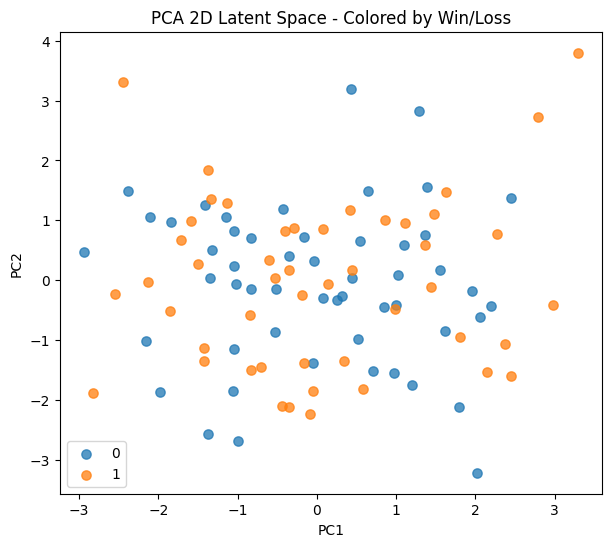

In [ ]:
plot_latent_space(
    X_test_pca_2,
    y_win_test.values,
    "PCA 2D Latent Space - Colored by Win/Loss",
    xlab="PC1",
    ylab="PC2"
)

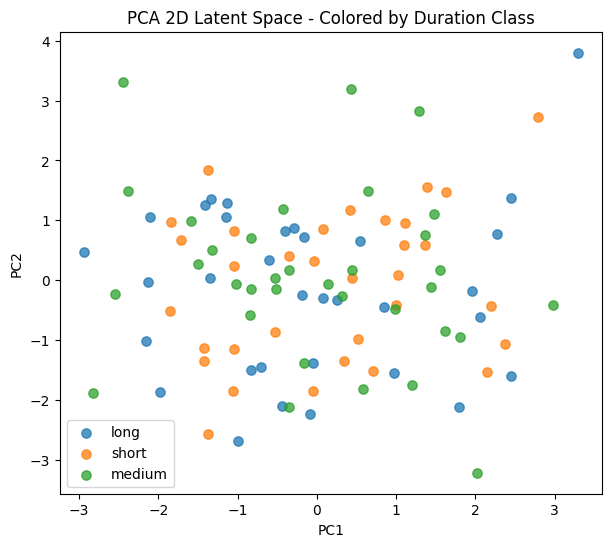

In [ ]:
plot_latent_space(
    X_test_pca_2,
    y_duration_test.values,
    "PCA 2D Latent Space - Colored by Duration Class",
    xlab="PC1",
    ylab="PC2"
)

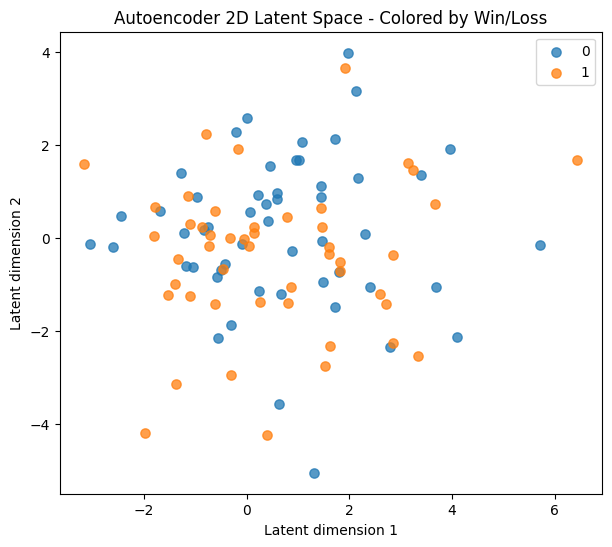

In [ ]:
plot_latent_space(
    X_test_ae_2,
    y_win_test.values,
    "Autoencoder 2D Latent Space - Colored by Win/Loss"
)

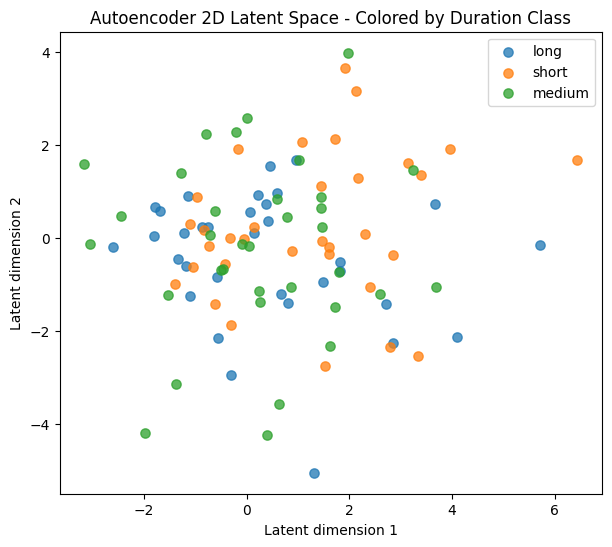

In [ ]:
plot_latent_space(
    X_test_ae_2,
    y_duration_test.values,
    "Autoencoder 2D Latent Space - Colored by Duration Class"
)

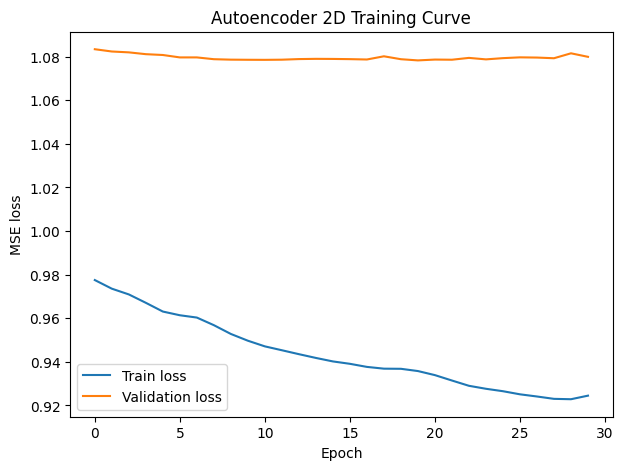

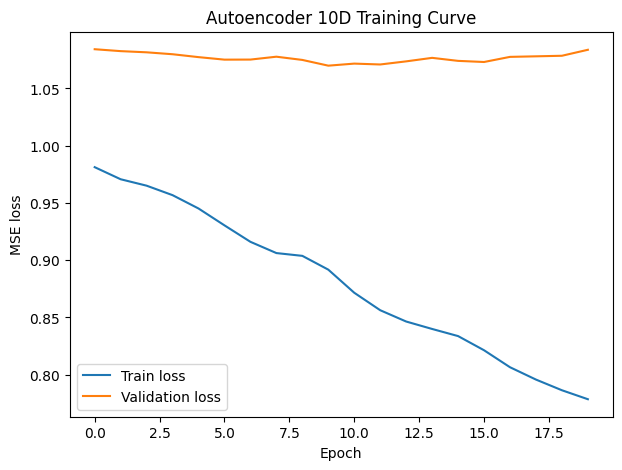

In [ ]:
# -------------------------
# Autoencoder training curves
# -------------------------
plt.figure(figsize=(7, 5))
plt.plot(history_2d.history["loss"], label="Train loss")
plt.plot(history_2d.history["val_loss"], label="Validation loss")
plt.title("Autoencoder 2D Training Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history_10d.history["loss"], label="Train loss")
plt.plot(history_10d.history["val_loss"], label="Validation loss")
plt.title("Autoencoder 10D Training Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.show()

In [ ]:
# -------------------------
# Split final results by task
# -------------------------
win_results = all_results[all_results["task"] == "win_loss"].copy()
duration_results = all_results[all_results["task"] == "duration_class"].copy()

display(win_results)
display(duration_results)

,task,model,accuracy,f1,roc_auc,macro_f1
0,win_loss,logistic_regression,0.60,0.6078,0.6390,NaN
1,win_loss,rbf_svc,0.61,0.5714,0.6082,NaN
4,win_loss,logistic_regression_pca10,0.50,0.3750,0.5264,NaN
5,win_loss,rbf_svc_pca10,0.50,0.4318,0.4135,NaN
8,win_loss,logistic_regression_ae10,0.47,0.3614,0.4579,NaN
9,win_loss,rbf_svc_ae10,0.50,0.4048,0.4860,NaN


,task,model,accuracy,f1,roc_auc,macro_f1
2,duration_class,logistic_regression,0.41,NaN,NaN,0.4086
3,duration_class,rbf_svc,0.36,NaN,NaN,0.3592
6,duration_class,logistic_regression_pca10,0.35,NaN,NaN,0.3483
7,duration_class,rbf_svc_pca10,0.30,NaN,NaN,0.2924
10,duration_class,logistic_regression_ae10,0.28,NaN,NaN,0.2808
11,duration_class,rbf_svc_ae10,0.31,NaN,NaN,0.3013


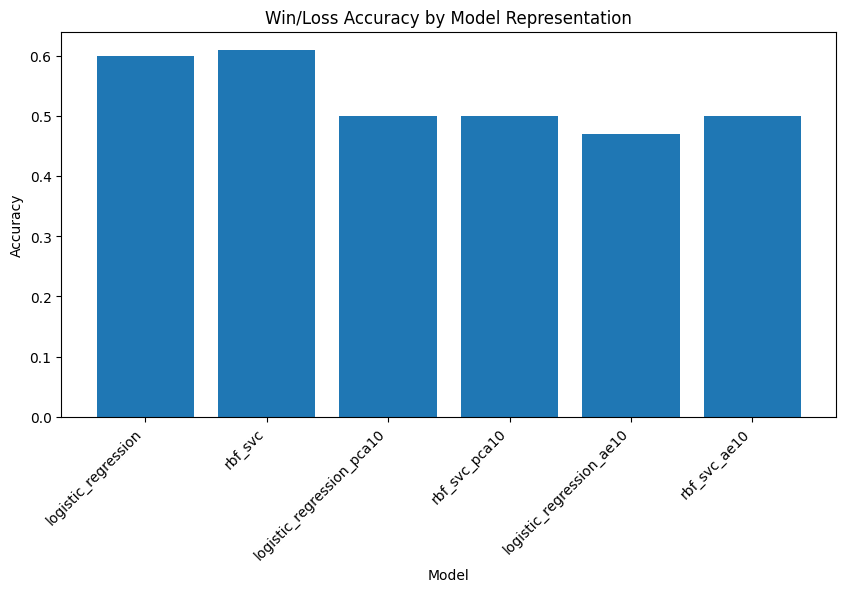

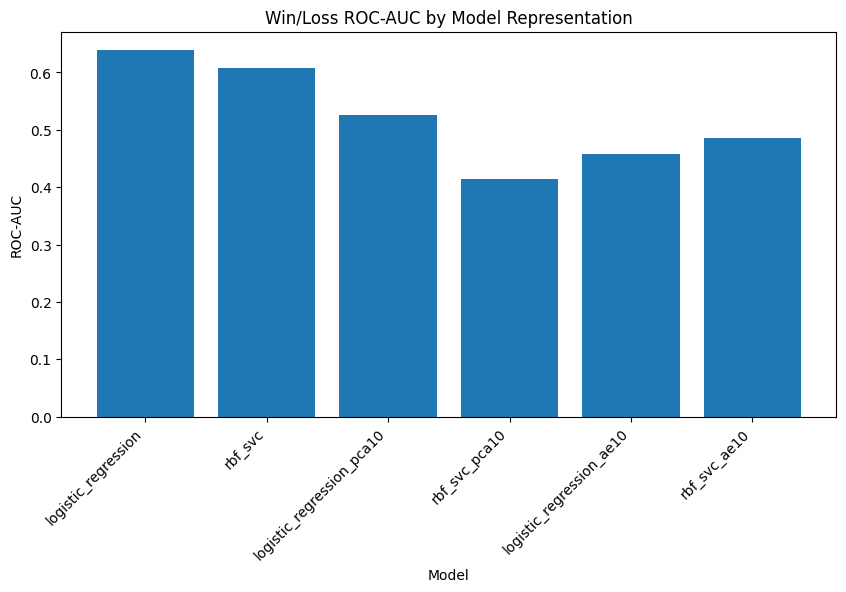

In [ ]:
# -------------------------
# Win/loss comparison chart
# -------------------------
win_plot = win_results.copy()

plt.figure(figsize=(10, 5))
plt.bar(win_plot["model"], win_plot["accuracy"])
plt.title("Win/Loss Accuracy by Model Representation")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(win_plot["model"], win_plot["roc_auc"])
plt.title("Win/Loss ROC-AUC by Model Representation")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
# -------------------------
# Save result tables
# -------------------------
results_summary.to_csv("results_raw_features.csv", index=False)
pca_results.to_csv("results_pca.csv", index=False)
ae_results.to_csv("results_autoencoder.csv", index=False)
all_results.to_csv("results_all_models.csv", index=False)

print("Saved results tables.")

Saved results tables.


In [ ]:
# get feature names
feature_names = X.columns

# extract trained logistic regression model from the pipeline
win_coef = logreg_win.named_steps["model"].coef_[0]

coef_df_win = pd.DataFrame({
    "feature": feature_names,
    "coefficient": win_coef
}).sort_values("coefficient", ascending=False)

print("Top features pushing prediction toward WIN:")
display(coef_df_win.head(15))

print("Top features pushing prediction toward LOSS:")
display(coef_df_win.tail(15))

Top features pushing prediction toward WIN:


,feature,coefficient
121,allyhero_36,0.812237
205,allyhero_131,0.742352
338,is_radiant,0.741205
144,allyhero_59,0.658231
39,myhero_64,0.648612
271,enemyhero_61,0.605391
232,enemyhero_21,0.604289
260,enemyhero_50,0.597836
94,allyhero_8,0.596504
158,allyhero_74,0.590120


Top features pushing prediction toward LOSS:


,feature,coefficient
138,allyhero_53,-0.544496
53,myhero_86,-0.547642
41,myhero_69,-0.550646
320,enemyhero_111,-0.643535
298,enemyhero_89,-0.644865
57,myhero_93,-0.650900
294,enemyhero_85,-0.714619
281,enemyhero_72,-0.719839
285,enemyhero_76,-0.728654
206,allyhero_135,-0.728845


In [ ]:
duration_classes = logreg_duration.named_steps["model"].classes_
duration_coefs = logreg_duration.named_steps["model"].coef_

for i, cls in enumerate(duration_classes):
    coef_df_dur = pd.DataFrame({
        "feature": X.columns,
        "coefficient": duration_coefs[i]
    }).sort_values("coefficient", ascending=False)

    print(f"\nTop features pushing prediction toward class: {cls}")
    display(coef_df_dur.head(10))

    print(f"Top features pushing prediction away from class: {cls}")
    display(coef_df_dur.tail(10))


Top features pushing prediction toward class: long


,feature,coefficient
141,allyhero_56,0.710810
9,myhero_15,0.501964
282,enemyhero_73,0.488843
77,myhero_123,0.462975
334,enemyhero_137,0.427460
132,allyhero_47,0.423233
203,allyhero_128,0.398958
174,allyhero_90,0.390097
129,allyhero_44,0.388912
266,enemyhero_56,0.381903


Top features pushing prediction away from class: long


,feature,coefficient
76,myhero_121,-0.390553
264,enemyhero_54,-0.405492
310,enemyhero_101,-0.407339
116,allyhero_31,-0.409496
131,allyhero_46,-0.420872
144,allyhero_59,-0.440542
147,allyhero_63,-0.472511
21,myhero_28,-0.489028
142,allyhero_57,-0.535020
233,enemyhero_22,-0.548687



Top features pushing prediction toward class: medium


...

,feature,coefficient
63,myhero_99,-0.356467
276,enemyhero_67,-0.363519
220,enemyhero_9,-0.373810
170,allyhero_86,-0.408358
15,myhero_21,-0.422162
129,allyhero_44,-0.434279
317,enemyhero_108,-0.472237
333,enemyhero_136,-0.540259
197,allyhero_114,-0.541037
141,allyhero_56,-0.607739



Top features pushing prediction toward class: short


,feature,coefficient
333,enemyhero_136,0.607704
337,enemyhero_155,0.489135
233,enemyhero_22,0.485034
142,allyhero_57,0.467987
6,myhero_10,0.441273
177,allyhero_93,0.433258
169,allyhero_85,0.426784
119,allyhero_34,0.425251
121,allyhero_36,0.412186
239,enemyhero_29,0.405825


Top features pushing prediction away from class: short


,feature,coefficient
105,allyhero_19,-0.405602
323,enemyhero_114,-0.406659
5,myhero_9,-0.415026
166,allyhero_82,-0.415285
17,myhero_23,-0.418732
77,myhero_123,-0.465611
194,allyhero_111,-0.496294
335,enemyhero_138,-0.555447
205,allyhero_131,-0.587499
114,allyhero_29,-0.708065
